In [1]:
from pathlib import Path
import sys
# Ensure workspace root is on sys.path so imports work from the notebook
root = Path.cwd()
while not (root / "L1_DataProcessing").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations

from L1_DataProcessing.IngestionPipeline import OrderBookDashboard

In [2]:
import matplotlib.pyplot as plt
from collections import deque
from IPython.display import display, clear_output
import time
import numpy as np
import networkx as nx

class ForexGraph:
    def __init__(self, dashboard, pairs, assets, broker_name="Binance", max_history=120, interval=0.5):
        self.dashboard = dashboard
        self.pairs = pairs
        self.assets = sorted([a.upper() for a in assets])
        self.broker_name = broker_name
        self.max_history = max_history
        self.interval = interval
        
        # Map pair strings to (base, quote) tuples
        self.pair_mapping = {}
        for pair in pairs:
            base, quote = self._parse_pair(pair)
            if base and quote:
                self.pair_mapping[pair] = (base, quote)
        
        # Track previous rates for change detection
        self.previous_rates = {}
        
        # Setup the plot with two subplots: graph and data table
        self.fig = plt.figure(figsize=(18, 10))
        self.ax_graph = self.fig.add_subplot(121)
        self.ax_table = self.fig.add_subplot(122)

    def _parse_pair(self, pair):
        """Parse a pair string using known assets."""
        pair_lower = pair.lower()
        for asset in self.assets:
            asset_lower = asset.lower()
            if pair_lower.startswith(asset_lower):
                base = asset
                quote_lower = pair_lower[len(asset_lower):]
                for asset2 in self.assets:
                    if asset2.lower() == quote_lower:
                        return base, asset2
            elif pair_lower.endswith(asset_lower):
                quote = asset
                base_lower = pair_lower[:-len(asset_lower)]
                for asset2 in self.assets:
                    if asset2.lower() == base_lower:
                        return asset2, quote
        return None, None

    def _draw(self):
        """Draw the exchange rate network graph with data table."""
        self.ax_graph.clear()
        self.ax_table.clear()
        
        # Create complete graph with all assets as nodes
        G = nx.complete_graph(len(self.assets))
        # Relabel nodes with asset names
        mapping = {i: self.assets[i] for i in range(len(self.assets))}
        G = nx.relabel_nodes(G, mapping)
        
        # Add exchange rates as edge labels
        edge_labels = {}
        rate_data = []
        broker_label = self.dashboard.get_broker() if hasattr(self.dashboard, 'get_broker') else self.broker_name
        for pair in self.pairs:
            if pair in self.pair_mapping:
                base, quote = self.pair_mapping[pair]
                bid, _ = self.dashboard.get_best_prices(pair)
                if bid != "N/A":
                    try:
                        rate = float(bid)
                        edge_labels[(base, quote)] = f"{rate:.4f}"
                        rate_data.append({
                            'broker': broker_label,
                            'pair': f"{base}/{quote}",
                            'rate': f"{rate:.6f}",
                            'stream': pair,
                            'value': rate
                        })
                    except Exception:
                        pass
        
        # Draw the network graph
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
        
        # Draw nodes
        nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=2000, ax=self.ax_graph)
        
        # Draw edges
        nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, ax=self.ax_graph)
        
        # Draw node labels
        nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold', ax=self.ax_graph)
        
        # Draw edge labels (exchange rates)
        if edge_labels:
            nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=9, ax=self.ax_graph)
        
        data_count = len(edge_labels)
        self.ax_graph.set_title(f"Exchange Rate Network ({len(self.assets)} assets) — Broker: {broker_label}")
        self.ax_graph.axis('off')
        
        # Draw data table
        self.ax_table.axis('tight')
        self.ax_table.axis('off')
        
        if rate_data:
            # Prepare cell text and colors
            cell_text = [[row['broker'], row['pair'], row['rate'], row['stream']] for row in rate_data]
            
            table = self.ax_table.table(
                cellText=cell_text,
                colLabels=['Broker', 'Pair', 'Rate', 'Stream'],
                cellLoc='center',
                loc='center',
                colWidths=[0.18, 0.26, 0.26, 0.3]
            )
            table.auto_set_font_size(False)
            table.set_fontsize(10)
            table.scale(1, 2)
            
            # Color header row
            for i in range(4):
                table[(0, i)].set_facecolor('#4CAF50')
                table[(0, i)].set_text_props(weight='bold', color='white')
            
            # Color rows based on rate changes
            for i, row in enumerate(rate_data, start=1):
                pair_key = row['pair']
                current_rate = row['value']
                
                if pair_key in self.previous_rates:
                    prev_rate = self.previous_rates[pair_key]
                    if current_rate > prev_rate:
                        change_color = '#90EE90'  # Light green (increase)
                    elif current_rate < prev_rate:
                        change_color = '#FFB6C6'  # Light red (decrease)
                    else:
                        change_color = '#f0f0f0'  # Light gray (no change)
                else:
                    change_color = '#f0f0f0'  # Light gray (first time)
                
                # Apply color to rate cell (index 2) only
                for j in range(4):
                    if j == 2:
                        table[(i, j)].set_facecolor(change_color)
                    else:
                        table[(i, j)].set_facecolor('#ffffff')
                
                self.previous_rates[pair_key] = current_rate
        
        self.ax_table.set_title(
            f"Live Exchange Rates ({data_count}/{len(self.pairs)} pairs) — Broker: {broker_label}",
            fontsize=12,
            fontweight='bold',
            pad=20
        )
        
        plt.tight_layout()
        display(self.fig)
        clear_output(wait=True)

    def run(self):
        """Update the graph continuously."""
        broker_label = self.dashboard.get_broker() if hasattr(self.dashboard, 'get_broker') else self.broker_name
        print(f"Waiting for {broker_label} dashboard data to populate...")
        time.sleep(2)  # Give dashboard time to collect initial data
        print(f"Starting {broker_label} graph updates...")
        
        try:
            update_count = 0
            while True:
                self._draw()
                update_count += 1
                if update_count % 10 == 0:
                    print(f"Updated {update_count} times...")
                time.sleep(self.interval)
        except KeyboardInterrupt:
            print("Graph stopped.")
            pass

    def show(self):
        """Start the live graph display."""
        self.run()

Updated 100 times...
Graph stopped.


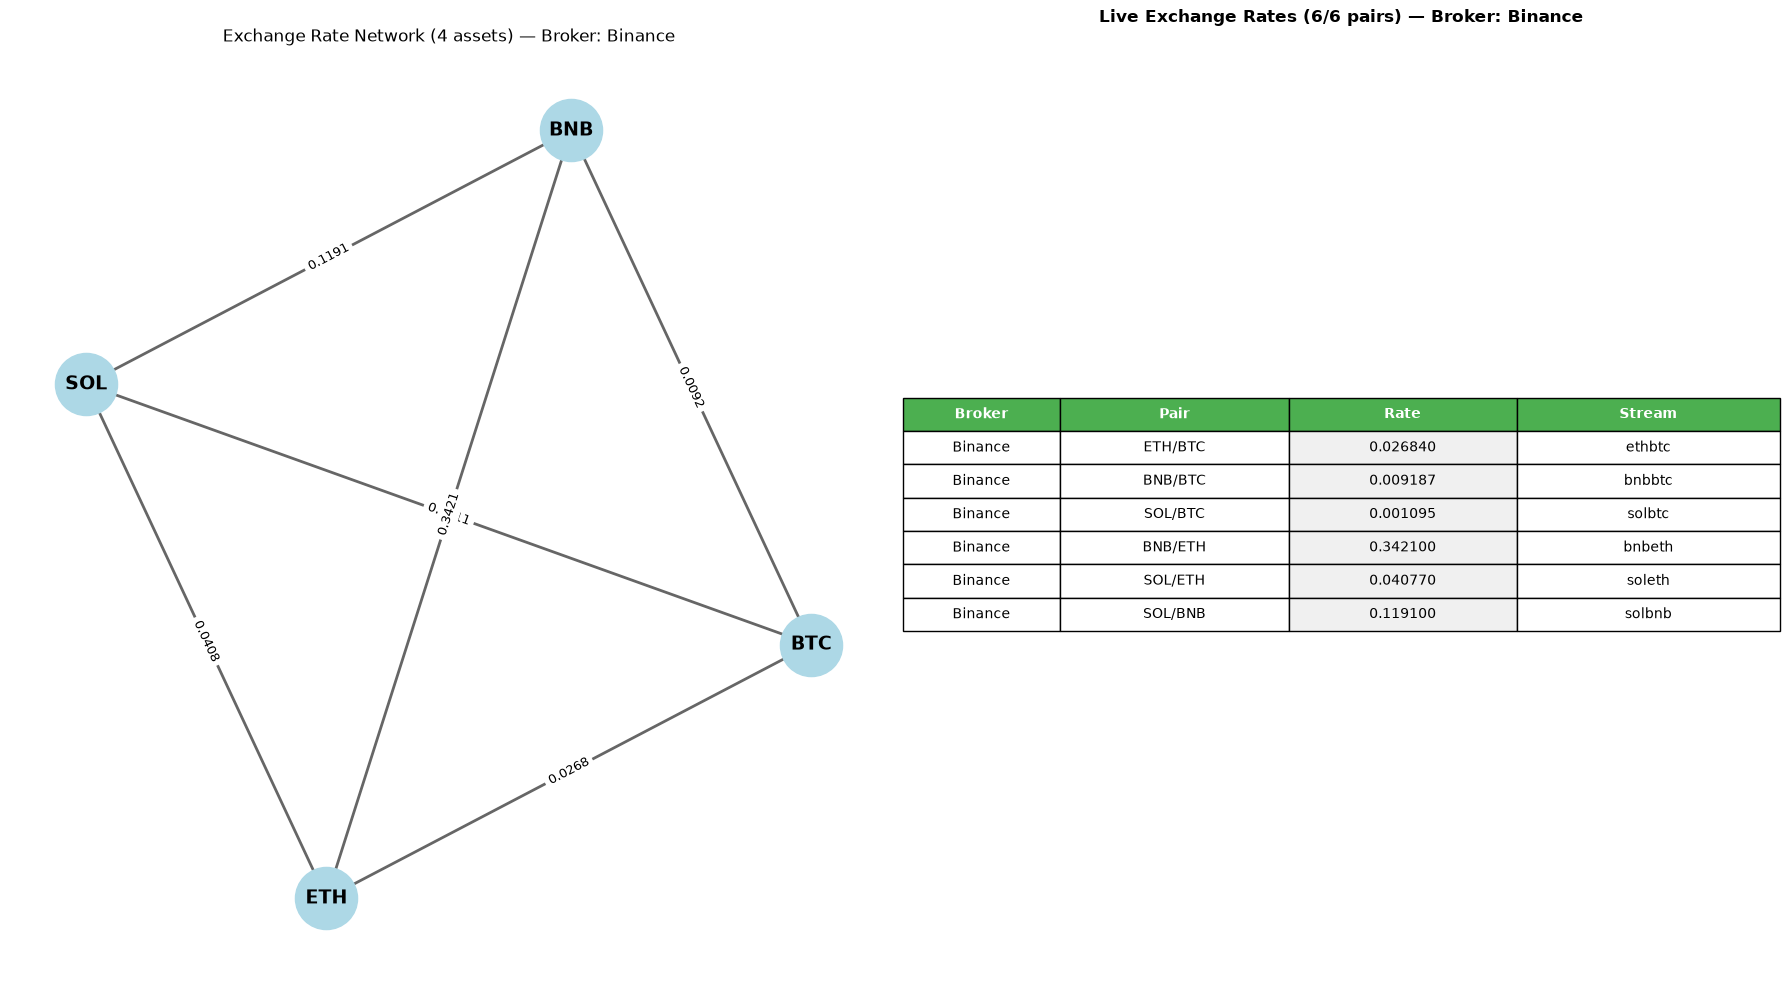

In [3]:
# Configuration
quote_priority = ["btc", "eth", "bnb", "sol"]
assets = ["btc", "eth", "bnb", "sol"]

def make_pair(a, b):
    base, quote = (b, a) if quote_priority.index(a) < quote_priority.index(b) else (a, b)
    return f"{base}{quote}"

# K4: every asset directly connected to every other asset (6 edges, no hub)
my_pairs = [make_pair(a, b) for a, b in combinations(assets, 2)]

# Broker URL mapping
broker_urls = {
    "Binance": (
        "wss://stream.binance.com:9443/stream?streams="
        + "/".join(f"{p}@depth5@100ms" for p in my_pairs)
    ),
    "OANDA": "wss://example.oanda.com/stream?pairs=EUR_USD,GBP_USD,AUD_USD",
    "IBKR": "wss://example.ibkr.com/stream?pairs=EURUSD,GBPUSD,AUDUSD"
}

# Choose your broker here
broker_name = "Binance"
url = broker_urls.get(broker_name)
if url is None:
    raise ValueError(f"Unknown broker: {broker_name}. Available brokers: {list(broker_urls)}")

refresh_rate = 0.1  # 100ms updates

print(f"Using broker: {broker_name}")
print(f"Stream URL: {url}")

dashboard = OrderBookDashboard(my_pairs, url, broker_name=broker_name, refresh_interval=refresh_rate, show=False)
dashboard.run()

# Create and display the live forex exchange rate graph
graph = ForexGraph(
    dashboard,
    my_pairs,
    assets,
    broker_name=broker_name,
    max_history=120,
    interval=refresh_rate  # Match graph update interval to dashboard refresh rate
)
graph.show()